In [1]:
import glob
import pandas as pd

folder_path = "/home/shawky/Documents/nti/actual nti/youtubenotebook/Notebooks_and_Dataset-20260812T144821Z-1-001/Notebooks_and_Dataset/youtube-dataset"

file_paths = glob.glob(f"{folder_path}/*.csv")

df_list = [pd.read_csv(file) for file in file_paths]
combined_df = pd.concat(df_list, ignore_index=True)


In [2]:
combined_df = combined_df.drop(columns=['COMMENT_ID' , 'AUTHOR' ,'DATE'])

In [3]:
combined_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1955 entries, 0 to 1954
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   CONTENT  1955 non-null   str  
 1   CLASS    1955 non-null   int64
dtypes: int64(1), str(1)
memory usage: 30.7 KB


In [4]:
combined_df.isnull().sum()

CONTENT    0
CLASS      0
dtype: int64

In [5]:
combined_df.duplicated().sum()

np.int64(196)

In [6]:
combined_df.drop_duplicates(inplace=True)

In [7]:
combined_df['CLASS'].value_counts()

CLASS
0    919
1    840
Name: count, dtype: int64

<Axes: xlabel='CLASS', ylabel='count'>

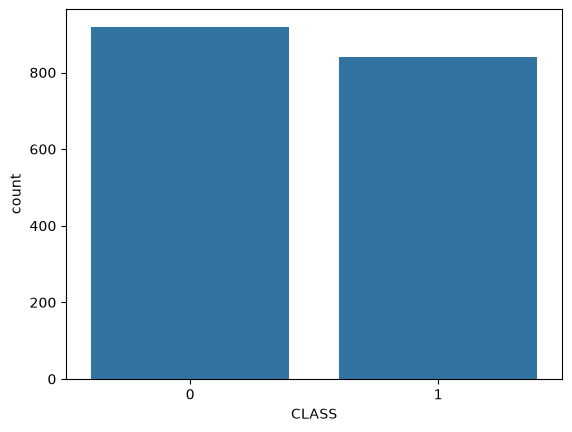

In [8]:
import seaborn as sns
sns.barplot(combined_df['CLASS'].value_counts())

In [9]:
x = combined_df.drop(['CLASS'], axis=1)
y = combined_df['CLASS']

In [10]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2, random_state=42, stratify = combined_df['CLASS'])

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

In [16]:
x_train_vec = vectorizer.fit_transform(x_train["CONTENT"])
x_test_vec = vectorizer.transform(x_test["CONTENT"])

In [17]:
x_train_vec.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1407, 3732))

In [18]:
x_train_vec.shape

(1407, 3732)

In [33]:
from sklearn.naive_bayes import MultinomialNB, ComplementNB
MB = MultinomialNB()

In [34]:
MB.fit(x_train_vec.toarray(),y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[735.,672.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.65,-0.74]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 3732)","[[ 2.,29., 1.,..., 1., 1., 1.], [ 4.,24., 0.,..., 0., 0., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 3732)","[[-8.13,-5.83,-8.54,...,-8.54,-8.54,-8.54], [-8.28,-6.67,-9.89,...,-9.89,-9.89,-9.89]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3732


In [ ]:
import numpy as np
np.(MB.class_log_prior_)

array([0.52238806, 0.47761194])

In [44]:
y_test_pred = MB.predict(x_test_vec)

In [59]:
MB.classes_

array([0, 1])

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

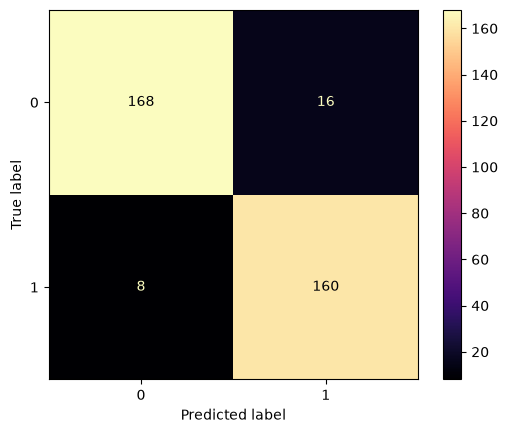

In [60]:
import matplotlib.pyplot as plt
sns.reset_orig()

ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    labels = MB.classes_,
    cmap = 'magma'
);
plt.show()